## Семинар №15 (Лабораторная работа №4)

В этой практической истории мы стремимся освоить расчет продуктовых метрик, когортный анализ и применение панельных регрессий. Вам будет предложено несколько упражнений и вопросов для решения. Результатом является `Jupyter Notebook` (`Rmd`-документ), подписанный как `Фамилия__Lab4.ipynb[.rmd]`. Сдача через SmartLMS (в соответствующий проект).

---

### Подготовка рабочей среды к анализу метрик

In [1]:
if (Sys.setlocale("LC_ALL", "en_US.UTF-8") == "C") {
    Sys.setlocale("LC_ALL", "C.UTF-8")
}
Sys.setenv(LANG = "en_US.UTF-8", LC_CTYPE = "en_US.UTF-8")

In [2]:
# Рекомендуемые библиотеки
suppressMessages(library(tidyverse))
suppressMessages(library(lubridate))
suppressMessages(library(plm))
suppressMessages(library(geepack))
suppressMessages(library(survival))
suppressMessages(library(pwr))
suppressMessages(library(zoo))

# Загрузка датасетов
olist_metrics <- read_csv("olist_metrics.csv", num_threads = readr_threads())
olist_panel <- read_csv("olist_paneldata.csv", num_threads = readr_threads())
telco_panel <- read_csv("telco_panel.csv", num_threads = readr_threads())
telco_surv <- read_csv("telco_survival.csv", num_threads = readr_threads())

# Приведение дат к формату
olist_metrics$purchase_date <- ymd_hms(olist_metrics$purchase_date)
olist_panel$month <- ymd(olist_panel$month)
olist_panel$cohort_month <- ymd(olist_panel$cohort_month)

Rows: 110189 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): customer_id, order_id, product_category_name, ab_group, category_m...
dbl  (9): price_final, review_score, delivery_delay, is_holiday_season, quar...
dttm (1): purchase_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 2315280 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): customer_id
dbl  (13): spent, orders_count, unique_categories, avg_log_price, holiday_or...
dttm  (2): month, cohort_month

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 227990 Columns: 30
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (18)

### Блок 1. Совместный разбор (База: 3 балла)

#### 1.1. Описательная статистика и анализ структуры датасетов

Давайте посмотрим на распределение ключевых переменных и поищем всякие "ловушки" либо странные переменные.

In [3]:
print(colnames(olist_metrics))
print(" ")
print(colnames(olist_panel))

 [1] "customer_id"               "order_id"                 
 [3] "purchase_date"             "price_final"              
 [5] "product_category_name"     "review_score"             
 [7] "delivery_delay"            "ab_group"                 
 [9] "category_main"             "is_holiday_season"        
[11] "quarter"                   "basket_quantity"          
[13] "log_price"                 "seller_id_bulky"          
[15] "importance_customer_coeff" "review_score_clean"       
[1] " "
 [1] "customer_id"         "month"               "spent"              
 [4] "orders_count"        "unique_categories"   "avg_log_price"      
 [7] "holiday_orders"      "is_active"           "is_high_value"      
[10] "spent_lag1"          "cat_diversity_lag1"  "cohort_month"       
[13] "cum_spent"           "future_churn_flag"   "category_stickiness"
[16] "random_noise_index" 


In [4]:
print(colnames(telco_panel))
print(" ")
print(colnames(telco_surv))

 [1] "customerID"            "gender"                "SeniorCitizen"        
 [4] "Partner"               "Dependents"            "tenure"               
 [7] "PhoneService"          "MultipleLines"         "InternetService"      
[10] "OnlineSecurity"        "OnlineBackup"          "DeviceProtection"     
[13] "TechSupport"           "StreamingTV"           "StreamingMovies"      
[16] "Contract"              "PaperlessBilling"      "PaymentMethod"        
[19] "MonthlyCharges"        "TotalCharges"          "Churn"                
[22] "churn_binary"          "month_index"           "total_calls_mins"     
[25] "num_support_tickets"   "referral_source"       "account_balance"      
[28] "risk_scoring_internal" "random_metric_xyz"     "is_churned_monthly"   
[1] " "
[1] "customerID"       "event_time"       "event_status"     "contract_type"   
[5] "MonthlyCharges"   "has_partner"      "has_dependents"   "is_fiber_optic"  
[9] "social_status_fk"


In [5]:
# Сводка по ценам и задержкам
summary(olist_metrics %>% select(price_final, delivery_delay, basket_quantity))

# Проверка корреляции "подозрительной" переменной из BI
cor_test <- cor.test(olist_metrics$price_final, olist_metrics$importance_customer_coeff)
print(paste("Корреляция цены и 'важности':", round(cor_test$estimate, 3)))

  price_final        delivery_delay     basket_quantity
 Min.   :   0.8075   Min.   :-146.016   Min.   :1      
 1st Qu.:  38.9700   1st Qu.: -16.320   1st Qu.:2      
 Median :  72.0000   Median : -12.046   Median :2      
 Mean   : 116.9777   Mean   : -11.332   Mean   :2      
 3rd Qu.: 129.9900   3rd Qu.:  -6.477   3rd Qu.:2      
 Max.   :6499.0000   Max.   : 188.975   Max.   :3      

[1] "Корреляция цены и 'важности': 0.998"


In [6]:
summary(olist_metrics)

    customer_id          order_id      purchase_date                
 Length   :110189   Length   :110189   Min.   :2016-09-15 12:16:38  
 N.unique : 96470   N.unique : 96470   1st Qu.:2017-09-15 04:33:29  
 N.blank  :     0   N.blank  :     0   Median :2018-01-21 09:13:09  
 Min.nchar:    32   Min.nchar:    32   Mean   :2018-01-02 02:38:47  
 Max.nchar:    32   Max.nchar:    32   3rd Qu.:2018-05-05 15:43:06  
                                       Max.   :2018-08-29 15:00:37  
                                       NAs    :1                    
  price_final        product_category_name  review_score   delivery_delay    
 Min.   :   0.8075   Length   :110189      Min.   :1.000   Min.   :-146.016  
 1st Qu.:  38.9700   N.unique :    73      1st Qu.:4.000   1st Qu.: -16.320  
 Median :  72.0000   N.blank  :     0      Median :5.000   Median : -12.046  
 Mean   : 116.9777   Min.nchar:     3      Mean   :4.082   Mean   : -11.332  
 3rd Qu.: 129.9900   Max.nchar:    46      3rd Qu.:5.000  

[1]  3848 24538

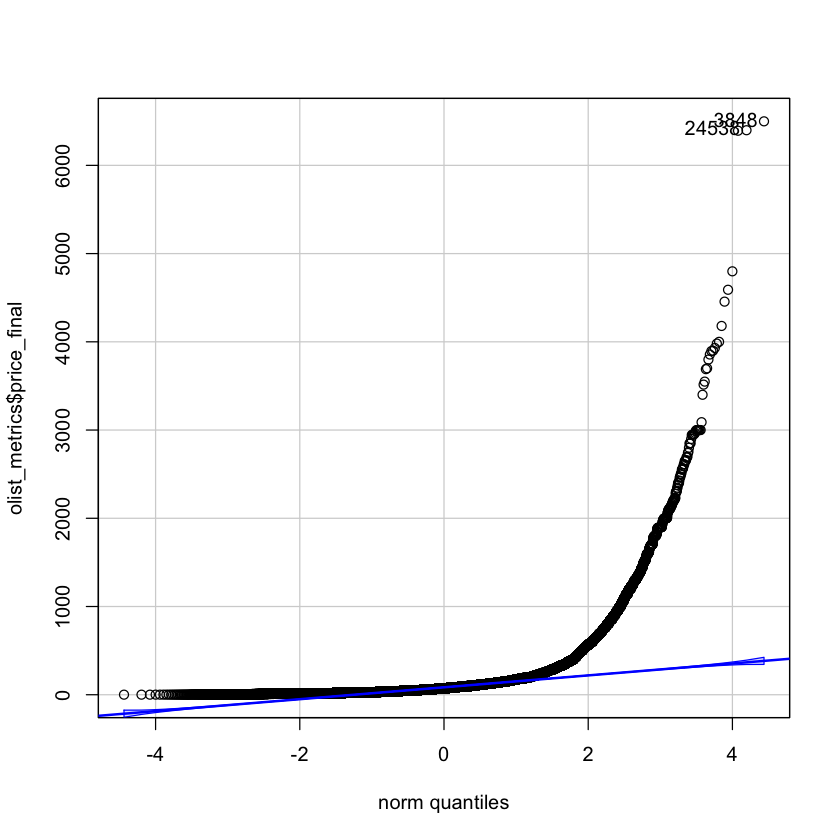

In [7]:
car::qqPlot(olist_metrics$price_final)

[1]  3848 24538

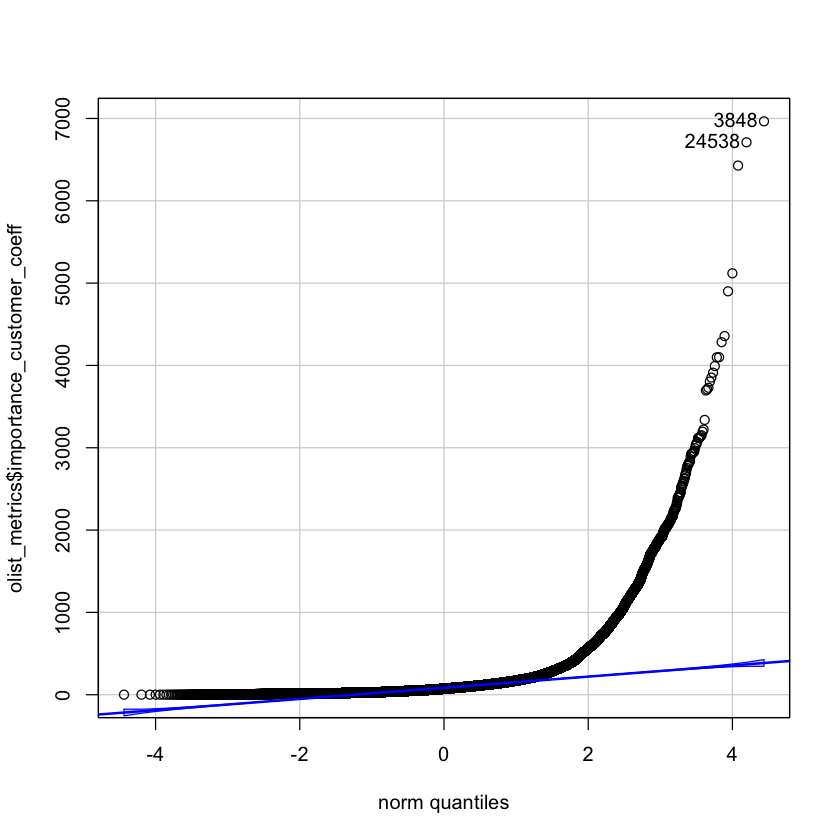

In [8]:
car::qqPlot(olist_metrics$importance_customer_coeff)

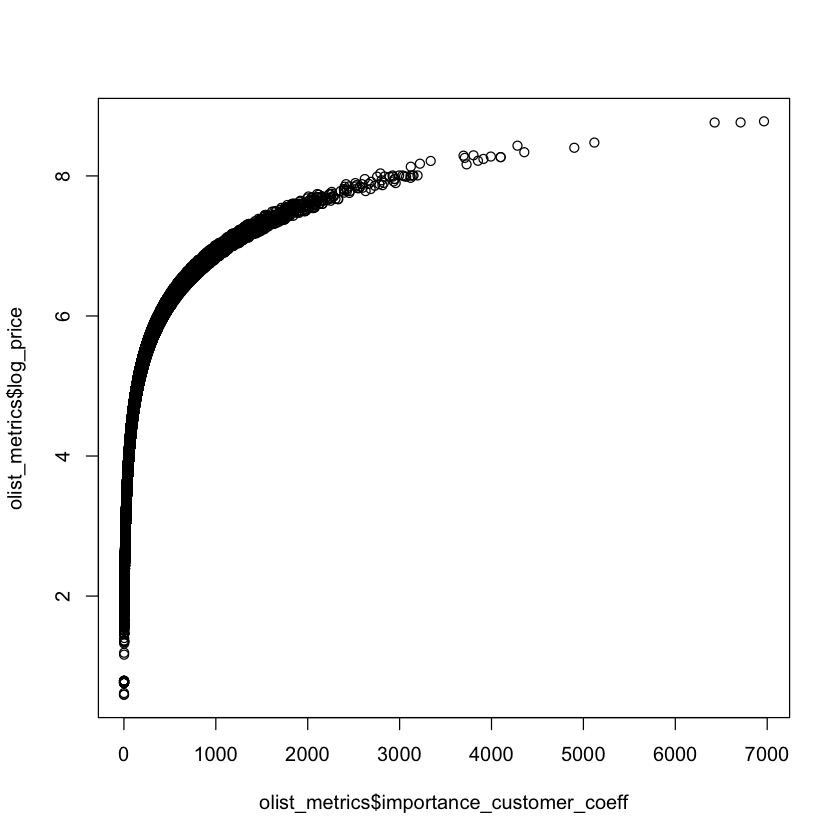

In [9]:
plot(olist_metrics$importance_customer_coeff, olist_metrics$log_price)

> Вопрос для самостоятельного ответа (в отчете):

Корреляция между price_final и importance_customer_coeff близка к 1. Объясните, почему включение обеих переменных в одну регрессионную модель является ошибкой (мультиколлинеарность). Какую из них вы бы оставили и почему?

**Ответ:**

Корреляция составляет 0.998: между переменными фактически наблюдается линейная зависимость ("важность клиента" напрямую зависит от цены покупки). Для регрессионной модели такие переменные практически неотличимы: они влияют на целевую переменную одинаково. Хотя это и не приведёт к ухудшению качества предсказаний, мультиколлинеарность не позволяет регрессии "понять", какую из переменных следует использовать на самом деле. В результате, значительно усложняется интерпретация модели: важность зависимости целевой переменной от price_final/importance_customer_coeff "размазывается" по двум коэффициентам произвольным и непредсказуемым образом, из‑за чего они становятся неустойчивыми и теряют смысл.

В общем случае оставить можно любую из переменных. Тем не менее в конкретных данных, с которыми мы работаем, я бы предпочёл сохранить цену покупки (price_final): этот признак является прямой и понятной бизнес-метрикой, непосредственно отражающей финансовые показатели. "Важность клиента" (importance_customer_coeff) звучит как странный агрегированный показатель, который требует уточнения; по доступной информации совершенно непонятно, как он получен и что за ним стоит (потенциально может быть утечка целевой переменной, если "важность" формируется по результатам покупки).

### 1.2. Расчет продуктовых метрик: RFM и Product Mix

Посчитаем не только деньги, но и разнообразие интересов клиента.

In [10]:
rfm_data <- olist_metrics %>%
  group_by(customer_id) %>%
  summarise(
    recency_days = as.numeric(difftime(max(olist_metrics$purchase_date), max(purchase_date), units = "days")),
    frequency = n_distinct(order_id),
    monetary_total = sum(price_final),
    unique_categories = n_distinct(category_main), # Разнообразие корзины
    avg_basket_qty = mean(basket_quantity)
  ) %>%
  mutate(
    R_score = ntile(-recency_days, 4),
    F_score = ntile(frequency, 4),
    M_score = ntile(monetary_total, 4)
  )

# Пример сегмента "Чемпионов" (высокие F и M)
champions <- rfm_data %>% filter(F_score >= 3 & M_score >= 3)
print(paste("Среднее количество категорий у чемпионов:", round(mean(champions$unique_categories), 2)))

[1] "Среднее количество категорий у чемпионов: 1.01"


In [11]:
rfm_data

customer_id,recency_days,frequency,monetary_total,unique_categories,avg_basket_qty,R_score,F_score,M_score
<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<int>
00012a2ce6f8dcda20d059ce98491703,NA,1,85.3100,1,1.0,NA,1,3
000161a058600d5901f007fab4c27140,NA,1,54.9000,1,2.0,NA,1,2
0001fd6190edaaf884bcaf3d49edf079,NA,1,179.9900,1,3.0,NA,1,4
0002414f95344307404f0ace7a26f1d5,NA,1,142.4050,1,2.0,NA,1,3
000379cdec625522490c315e70c7a9fb,NA,1,93.0000,1,1.0,NA,1,3
0004164d20a9e969af783496f3408652,NA,1,59.9900,1,2.0,NA,1,2
000419c5494106c306a97b5635748086,NA,1,32.5850,1,2.0,NA,1,1
00046a560d407e99b969756e0b10f282,NA,1,120.9000,1,2.0,NA,1,3
00050bf6e01e69d5c0fd612f1bcfb69c,NA,1,66.4905,1,2.0,NA,1,2


> Вопрос для самостоятельного ответа (в отчете):

Сравните avg_basket_qty для категории "electronics" и "food_drink". Как разница в количестве товаров влияет на стратегию упаковки и логистики для этих категорий?

In [12]:
olist_metrics %>%
  mutate(cat_group = case_when(
    category_main == "eletronicos" ~ "electronics",
    category_main %in% c("alimentos", "bebidas") ~ "food_drink"
  )) %>%
  filter(!is.na(cat_group)) %>%
  group_by(cat_group) %>%
  summarise(avg_basket_qty = mean(basket_quantity), n = n())

cat_group,avg_basket_qty,n
<chr>,<dbl>,<int>
electronics,1.994503,2729
food_drink,1.976971,1129


**Ответ:**

Среднее число товаров в корзине (avg_basket_qty) практически не отличается для этих категорий: в обоих случаях значение около 2-х товаров. Данных по логистике и стратегии упаковки у нас нет, но тем не менее можно с высокой уверенностью утверждать, что разница в количестве товаров не влияет на упаковку и логистику. В этих аспектах гораздо важнее структура товара (хрупкий, тяжелый, требует охлаждение и др.), а не размер корзины.


### 1.3. Углубленный когортный анализ (Cumulative ARPU)

Посмотрим, как накапливается доход от клиентов разных когорт.

Warning message:
“Removed 208 rows containing missing values or values outside the scale range
(`geom_line()`).”


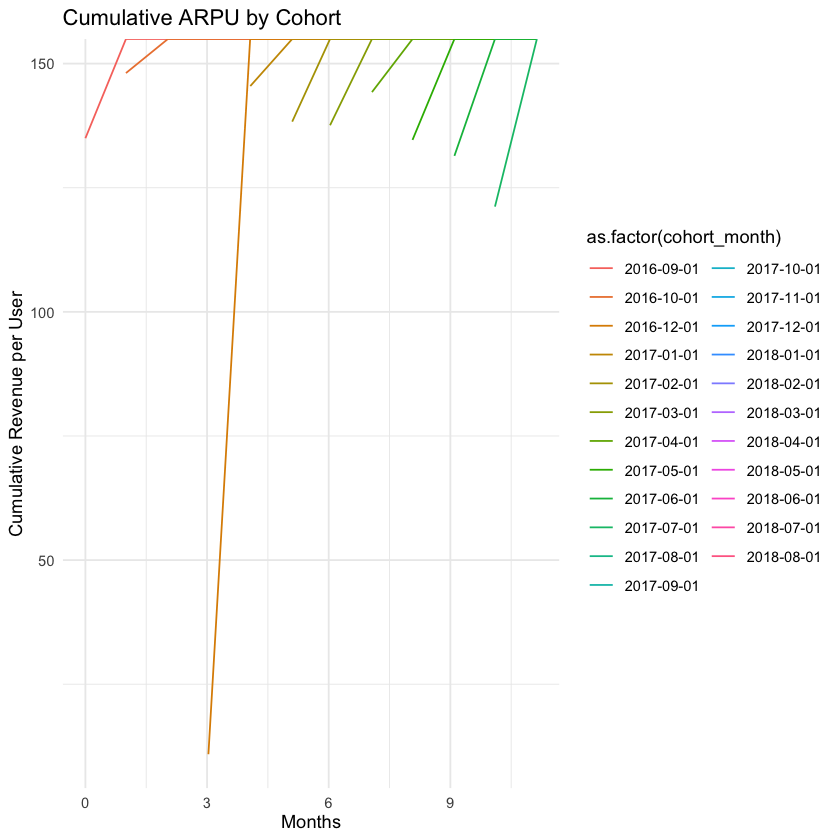

In [13]:
cohort_arpu <- olist_panel %>%
  group_by(cohort_month, month) %>%
  summarise(
    monthly_revenue = sum(spent),
    cohort_size = first(sum(is_active == 1 & month == min(month))),
    .groups = "drop"
  ) %>%
  arrange(cohort_month, month) %>%
  group_by(cohort_month) %>%
  mutate(
    cum_revenue = cumsum(monthly_revenue),
    cum_arpu = cum_revenue / cohort_size,
    months_since_start = as.numeric(difftime(month, min(month), units = "days")) / 30
  )

# Визуализация
ggplot(cohort_arpu %>% filter(months_since_start <= 12), 
       aes(x = months_since_start, y = cum_arpu, color = as.factor(cohort_month))) +
  geom_line() +
  labs(title = "Cumulative ARPU by Cohort", x = "Months", y = "Cumulative Revenue per User") +
  theme_minimal()

> Вопрос для самостоятельного ответа (в отчете):

Посмотрите на график. Какая когорта имеет самый крутой рост ARPU в первые 3 месяца? С чем это может быть связано (сезонность, маркетинговая акция, изменение ассортимента)?

In [14]:
olist_metrics %>%
  mutate(purchase_month = floor_date(purchase_date, "month")) %>%
  group_by(purchase_month) %>%
  summarise(
    orders = n(),
    revenue = sum(price_final),
    is_holiday_season = max(is_holiday_season),
  ) %>%
  filter(purchase_month >= ymd("2016-09-01"), purchase_month <= ymd("2017-01-01"))

purchase_month,orders,revenue,is_holiday_season
<dttm>,<int>,<dbl>,<dbl>
2016-09-01,3,134.97,0
2016-10-01,313,39244.04,0
2016-12-01,1,10.90,1
2017-01-01,913,109106.64,0


**Ответ:**

Самый крутой рост ARPU в первые 3 месяца наблюдается у когорты 2026-10-01: значение метрики резко увеличивается с фактически нуля до более 150.

Судя по графику, подобные скачки (хотя и не столь явные) случаются каждые пару месяцев, что намекает на некоторую сезонность. Однако октябрьская когорта не соотносится ни с какими праздниками, а информация об изменении ассортимента в данных не представлена. Таким образом, наиболее вероятное объяснение - регулярная маркетинговая кампания, которая привела к резкому скачку заказов: с 3 единиц в сентябре до 313 единиц в октябре.


In [15]:
telco_metrics <- telco_panel %>%
  group_by(customerID) %>%
  summarise(
    # 1. Tenure (Срок жизни) - уже есть, но можно пересчитать из панели
    tenure_calc = max(month_index),
    
    # 2. Средний чек (ARPU) за весь период наблюдения
    avg_arpu = mean(MonthlyCharges),
    
    # 3. Total Revenue (LTV proxy)
    total_revenue = sum(MonthlyCharges),
    
    # 4. Интенсивность обращений в поддержку (на 1 месяц жизни)
    support_intensity = sum(num_support_tickets) / max(month_index),
    
    # 5. Факт оттока
    is_churned = max(is_churned_monthly)
  ) %>%
  mutate(
    # Сегментация по сроку жизни
    tenure_segment = case_when(
      tenure_calc <= 12 ~ "New (<1 year)",
      tenure_calc <= 36 ~ "Mid (1-3 years)",
      TRUE ~ "Loyal (>3 years)"
    )
  )

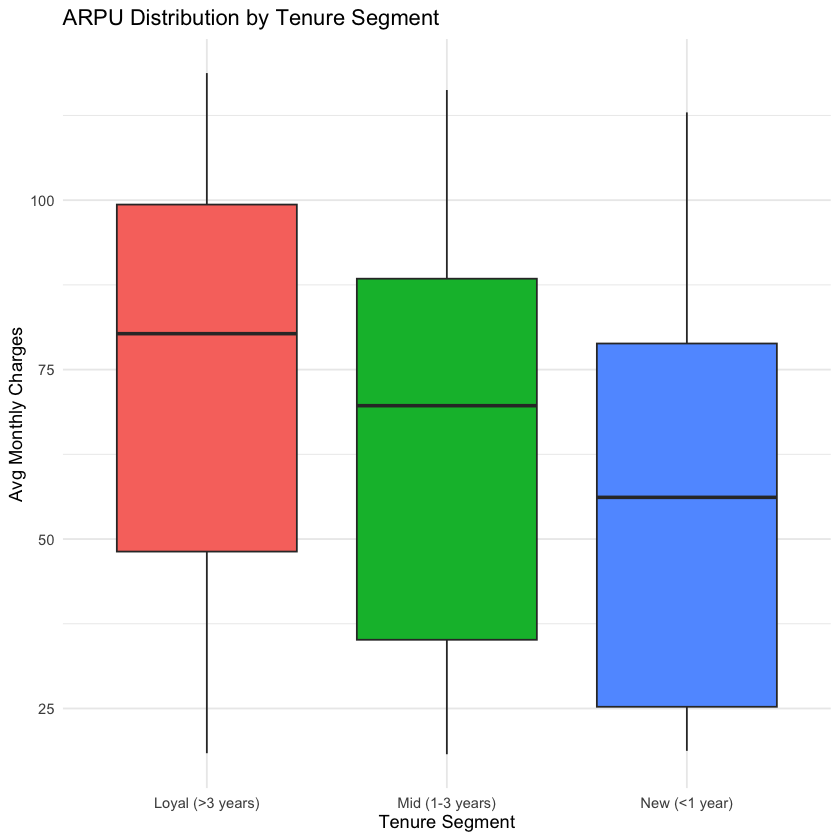

In [16]:
# Как ARPU зависит от сегмента лояльности?
ggplot(telco_metrics, aes(x = tenure_segment, y = avg_arpu, fill = tenure_segment)) +
  geom_boxplot() +
  labs(title = "ARPU Distribution by Tenure Segment", x = "Tenure Segment", y = "Avg Monthly Charges") +
  theme_minimal() +
  theme(legend.position = "none")

> Вопросы по ходу вывода:

1. Коррелирует ли support_intensity с фактом оттока (is_churned)? Является ли высокая нагрузка на поддержку причиной ухода или следствием проблем с сервисом?
2. Почему у новых клиентов (New <1 year) разброс ARPU часто выше, чем у лояльных? (Подсказка: промо-тарифы vs стабильные планы)
3. Если вы построите модель оттока и включите туда risk_scoring_internal, она покажет идеальную точность. Почему это плохо? 

In [17]:
print(cor.test(telco_metrics$support_intensity, telco_metrics$is_churned))
telco_metrics %>%
  group_by(is_churned) %>%
  summarise(mean_support = mean(support_intensity), n = n())


	Pearson's product-moment correlation

data:  telco_metrics$support_intensity and telco_metrics$is_churned
t = 29.935, df = 7030, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.3153404 0.3568049
sample estimates:
      cor 
0.3362356 



is_churned,mean_support,n
<dbl>,<dbl>,<int>
0,0.8088759,5163
1,1.3777389,1869


> 1. Коррелирует ли support_intensity с фактом оттока (is_churned)? Является ли высокая нагрузка на поддержку причиной ухода или следствием проблем с сервисом?

**Ответ:**

Корреляция интенсивности обращений в поддержку с оттоком ненулевая. Более того, этот результат статистически значим. У ушедших количество обращений в 1.7 раз больше, чем у оставшихся.

Высокая нагрузка на поддержку является скорее следствиев проблем с сервисом. Обычно люди не пишут в поддержку просто так, чтобы потом уйти из сервиса. Обращение в поддержку обычно является следствие проблем с сервисом, которые и являются первопричиной ухода.

> 2. Почему у новых клиентов (New <1 year) разброс ARPU часто выше, чем у лояльных? (Подсказка: промо-тарифы vs стабильные планы)

**Ответ:**

Новые клиенты обычно находятся на пробных промо-планах, стоимость которых сильно зависит от пути привлечения клиента: некоторые платят минимальную цену, а другие - полную. Новые клиенты также более склонны пробовать различные тарифы от самых дешевых до самых дорогих, что увеличивает разброс ARPU.

Лояльные клиенты же зачастую находятся на стабильных контрактах с фиксированной ценой, что делает распределение более компактным.

In [18]:
churn_data <- telco_panel %>%
  group_by(customerID) %>%
  summarise(
    tenure = max(month_index),
    avg_arpu = mean(MonthlyCharges),
    total_tickets = sum(num_support_tickets),
    contract_fct = factor(first(Contract), levels = c("Month-to-month", "One year", "Two year")),
    risk = first(risk_scoring_internal),
    is_churned = max(is_churned_monthly)
  )

acc <- function(m) mean((predict(m, type = "response") > 0.5) == churn_data$is_churned)

all <- glm(
  is_churned ~ tenure + avg_arpu + total_tickets + contract_fct + risk,
  data = churn_data,
  family = binomial
)
print(acc(all))

no_risk <- glm(
  is_churned ~ tenure + avg_arpu + total_tickets + contract_fct,
  data = churn_data,
  family = binomial
)
print(acc(no_risk))

[1] 0.7844141
[1] 0.7842719


> 3. Если вы построите модель оттока и включите туда risk_scoring_internal, она покажет идеальную точность. Почему это плохо? 

Модель glm не показывает идеальную точность. Более того, включение risk_scoring_internal даже не очень сильно улучшает результат.

Включение risk_scoring_internal может быть плохо, так как создает риск утечки. Перед использованием необходимо наверняка убедиться, что значение риска не зависит от целевой переменной и рассчитывается только по описанию клиента, не основываясь на результате работы с ним пост-фактум. Однако в нашей случае совершенно не похоже, что такая проблема наблюдается.

         (Intercept)               tenure             avg_arpu 
               0.223                0.988                1.029 
       total_tickets contract_fctOne year contract_fctTwo year 
               0.981                0.151                0.045 


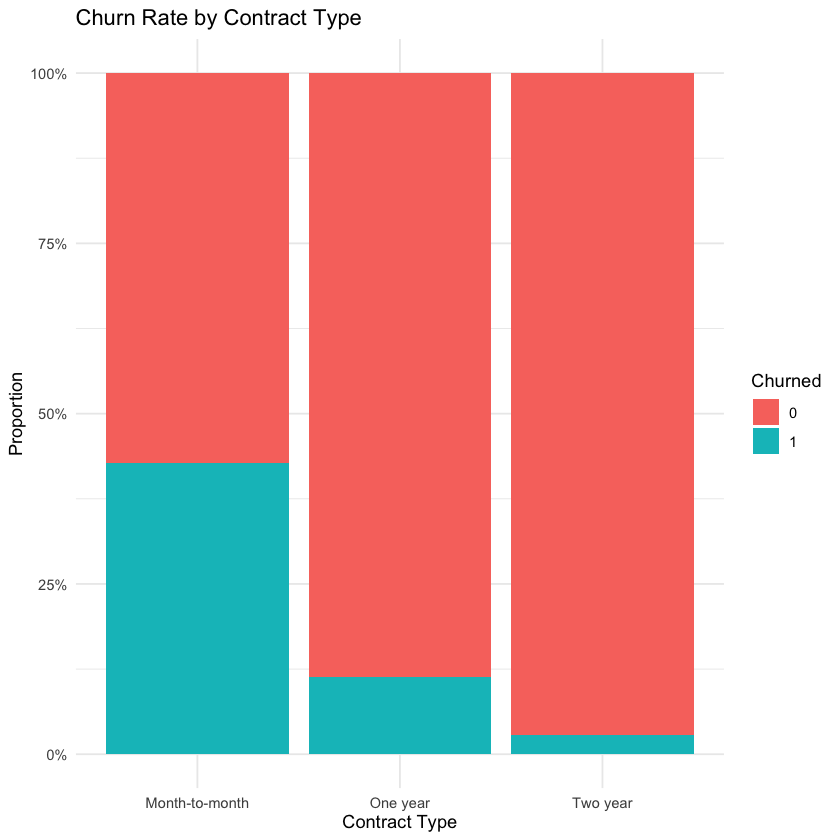

In [19]:
# Модель оттока
# Используем агрегированные данные по клиентам из панели
churn_model_data <- telco_panel %>%
  group_by(customerID) %>%
  summarise(
    tenure = max(month_index),
    avg_arpu = mean(MonthlyCharges),
    total_tickets = sum(num_support_tickets),
    contract_type = first(Contract),
    is_churned = max(is_churned_monthly) # Целевая переменная: 1 - ушел, 0 - остался
  ) %>%
  ungroup() %>%
  mutate(
    # Преобразуем контракт в фактор для регрессии
    contract_fct = factor(contract_type, levels = c("Month-to-month", "One year", "Two year"))
  )

# Логистическая регрессия (предсказание оттока)
churn_logit <- glm(
  is_churned ~ tenure + avg_arpu + total_tickets + contract_fct,
  data = churn_model_data, family = binomial(link = "logit")
)

# Интерпретация через Odds Ratios (экспоненцированные коэффициенты)
odds_ratios <- exp(coef(churn_logit))
print(round(odds_ratios, 3))
# или questionr::odds_ratio + avg_slopes()

# Визуализация влияния контракта на вероятность оттока
ggplot(churn_model_data, aes(x = contract_fct, fill = factor(is_churned))) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    title = "Churn Rate by Contract Type",
    x = "Contract Type",
    y = "Proportion",
    fill = "Churned"
  ) +
  theme_minimal()

In [20]:
churn_model_data

customerID,tenure,avg_arpu,total_tickets,contract_type,is_churned,contract_fct
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<fct>
0002-ORFBO,9,65.60,1,One year,0,One year
0003-MKNFE,9,59.90,14,Month-to-month,0,Month-to-month
0004-TLHLJ,4,73.90,7,Month-to-month,1,Month-to-month
0011-IGKFF,13,98.00,14,Month-to-month,1,Month-to-month
0013-EXCHZ,3,83.90,2,Month-to-month,1,Month-to-month
0013-MHZWF,9,69.40,12,Month-to-month,0,Month-to-month
0013-SMEOE,71,109.70,18,Two year,0,Two year
0014-BMAQU,63,84.65,12,Two year,0,Two year
0015-UOCOJ,7,48.20,16,Month-to-month,0,Month-to-month


### 1.4. Формулирование гипотез

Сформулируйте по одной конкретной гипотезе (с цифрами или фактами из анализа выше) для:

1. Маркетинга: (например, про реактивацию "спящих" клиентов).
2. Логистики: (например, про влияние задержек на повторные покупки).
3. DS-команды: (какой признак из olist_metrics был бы самым важным для модели оттока?).

**Ответ:**

1. **Маркетинг.** Наиболее вероятная причина резкого роста ARPU для когорты, сформированной в октябре 2016, - маркетинговая, а не сезонная. Следовательно, можно предположить, что целенаправленные маркетинговые кампании являются эффективным инструментов для краткосрочного привлечения доходных новых клиентов.

2. **Логистика.** Наблюдается большой разброс во времени доставки заказа: от -146 до 189 дней. Хотя средняя задержка и составляет -11.3 дня, то есть заказы в среднем поступают раньше обещанного срока, большие задержки крайне отрицательно влияют на рейтинг (минимальная оценка 1.0, средняя 4.08). Таким образом, целесообразно предположить, что более предсказуемое время доставки (по крайне мере без задержки) положительно скажется на удовлетворенности клиентов и снизит отток.

3. **DS.** В данных наблюдается высокая корреляция между "важностью клиента" и стоимостью покупки. Если предположить, что "важность клиента" формируется пост-фактум на основе данных оттока, то разумной гипотезой является предположение, что наиболее важным признаком для модели оттока является непосредственно стоимость покупки.

## Блок 2. Самостоятельная работа повышенной сложности (+7 баллов)

Выполнены все три задания (2.1–2.3).


### Задание 2.1. Дизайн и ловушки A/B-теста (3.5 балла)

Контекст: Мы тестируем новую фичу (скидку в Olist или новый тариф в Telco).

1. Power Analysis: Рассчитайте необходимый размер выборки для обнаружения эффекта в 5% при мощности 0.8.
2. Проверка SRM: Проверьте через chisq.test, не нарушена ли пропорция 50/50 в сегментах.
3. Парадокс Симпсона: Сравните общий эффект теста и эффект внутри сегментов.

> Вопросы для отчета:
1. Почему агрегированный результат теста может отличаться от результатов внутри сегментов?
2. Нашли ли вы признаки нарушения рандомизации (SRM)?
3. Какую группу клиентов в итоге стоит таргетировать этой фичей?


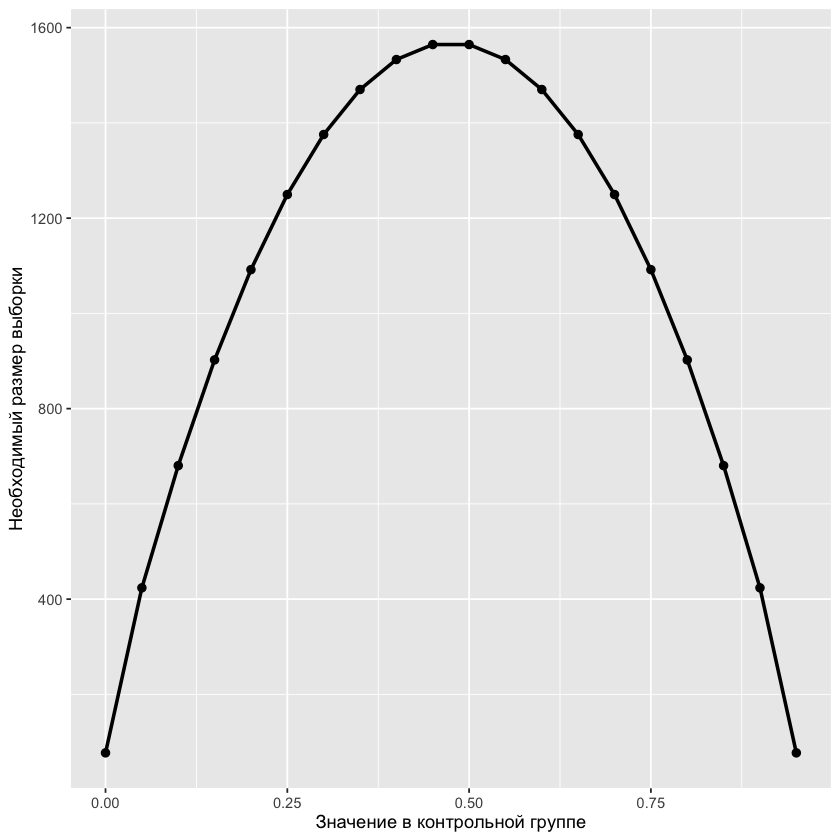

In [21]:
power_sensitivity <- tibble(p_control = seq(0.0, 0.95, by = 0.05)) %>%
  mutate(
    p_treatment = p_control + 0.05,
    h = map2_dbl(p_control, p_treatment, ~ ES.h(.x, .y)),
    n_per_group = map_dbl(
      h, ~ pwr.2p.test(h = .x, sig.level = 0.05, power = 0.8, alternative = "two.sided")$n
    )
  )

ggplot(power_sensitivity, aes(x = p_control, y = n_per_group)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(x = "Значение в контрольной группе", y = "Необходимый размер выборки")

Для обнаружения эффекта в 5% при мощности 0.8, в зависимости от начального значения метрики в контрольной группе, необходим размер выборки от менее 100 до почти 1600 наблюдаений. Ожидаемо, при экстремальном значении метрики (возле нуля или единицы), когда все "идет очень плохо или очень хорошо", для обнаружения эффекта требуется меньше наблюдений, чем при значении метрики около 0.5, когда результат может быть совершенно не однозначным.

In [22]:
print(table(olist_metrics$ab_group))
chisq.test(table(olist_metrics$ab_group), p = c(0.5, 0.5))


  Control Treatment 
    54907     55282 



	Chi-squared test for given probabilities

data:  table(olist_metrics$ab_group)
X-squared = 1.2762, df = 1, p-value = 0.2586


In [23]:
olist_metrics %>%
  group_by(category_main) %>%
  summarise(
    n = n(),
    n_control = sum(ab_group == "Control"),
    n_treatment = sum(ab_group == "Treatment"),
    srm_p = chisq.test(table(ab_group), p = c(0.5, 0.5))$p.value
  ) %>%
  mutate(srm_sig = if_else(srm_p < 0.05, "bad", "ok")) %>%
  arrange(desc(n))

Warning message:
“There were 2 warnings in `summarise()`.
The first warning was:
ℹ In argument: `srm_p = chisq.test(table(ab_group), p = c(0.5, 0.5))$p.value`.
ℹ In group 38: `category_main = "pc"`.
Caused by warning in `chisq.test()`:
! Chi-squared approximation may be incorrect
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


category_main,n,n_control,n_treatment,srm_p,srm_sig
<chr>,<int>,<int>,<int>,<dbl>,<chr>
cama,10953,5462,5491,0.78170581,ok
moveis,10737,5301,5436,0.19262815,ok
beleza,9465,4681,4784,0.28973198,ok
esporte,8430,4167,4263,0.29575479,ok
informatica,7643,3851,3792,0.49975840,ok
utilidades,6795,3429,3366,0.44470740,ok
relogios,5857,2898,2959,0.42541490,ok
telefonia,4685,2368,2317,0.45621042,ok
ferramentas,4268,2128,2140,0.85426212,ok


p-value почти 0.26 позволяет с уверенностью утверждать, что пропорция не нарушена (на уровне значимость 95% эту гипотезу следует считать верной). Это подтверждается и эмпирически: в Control отнесено 54907 наблюдение, а в Treatment - 55282; соотношение близко к 50/50.

Аналогичный результат и при анализе отдельных категорий товаров. Ни в одной из категорий не наблюдается статистически значимого нарушения пропорций, хотя отдельные небольшие категории (cds, pcs, casa) достаточно близки к этому.

In [24]:
t_overall <- t.test(price_final ~ ab_group, data = olist_metrics)
t_overall


	Welch Two Sample t-test

data:  price_final by ab_group
t = 6.2863, df = 109664, p-value = 3.263e-10
alternative hypothesis: true difference in means between group Control and group Treatment is not equal to 0
95 percent confidence interval:
 4.636687 8.837848
sample estimates:
  mean in group Control mean in group Treatment 
               120.3578                113.6206 


In [25]:
ab_cat_test <- olist_metrics %>%
  group_by(category_main) %>%
  summarise(
    n = n(),
    mean_control = mean(price_final[ab_group == "Control"]),
    mean_treatment = mean(price_final[ab_group == "Treatment"]),
    p_value = tryCatch(t.test(price_final ~ ab_group)$p.value, error = function(e) NA_real_)
  ) %>%
  mutate(diff = mean_treatment - mean_control) %>%
  arrange(desc(diff))

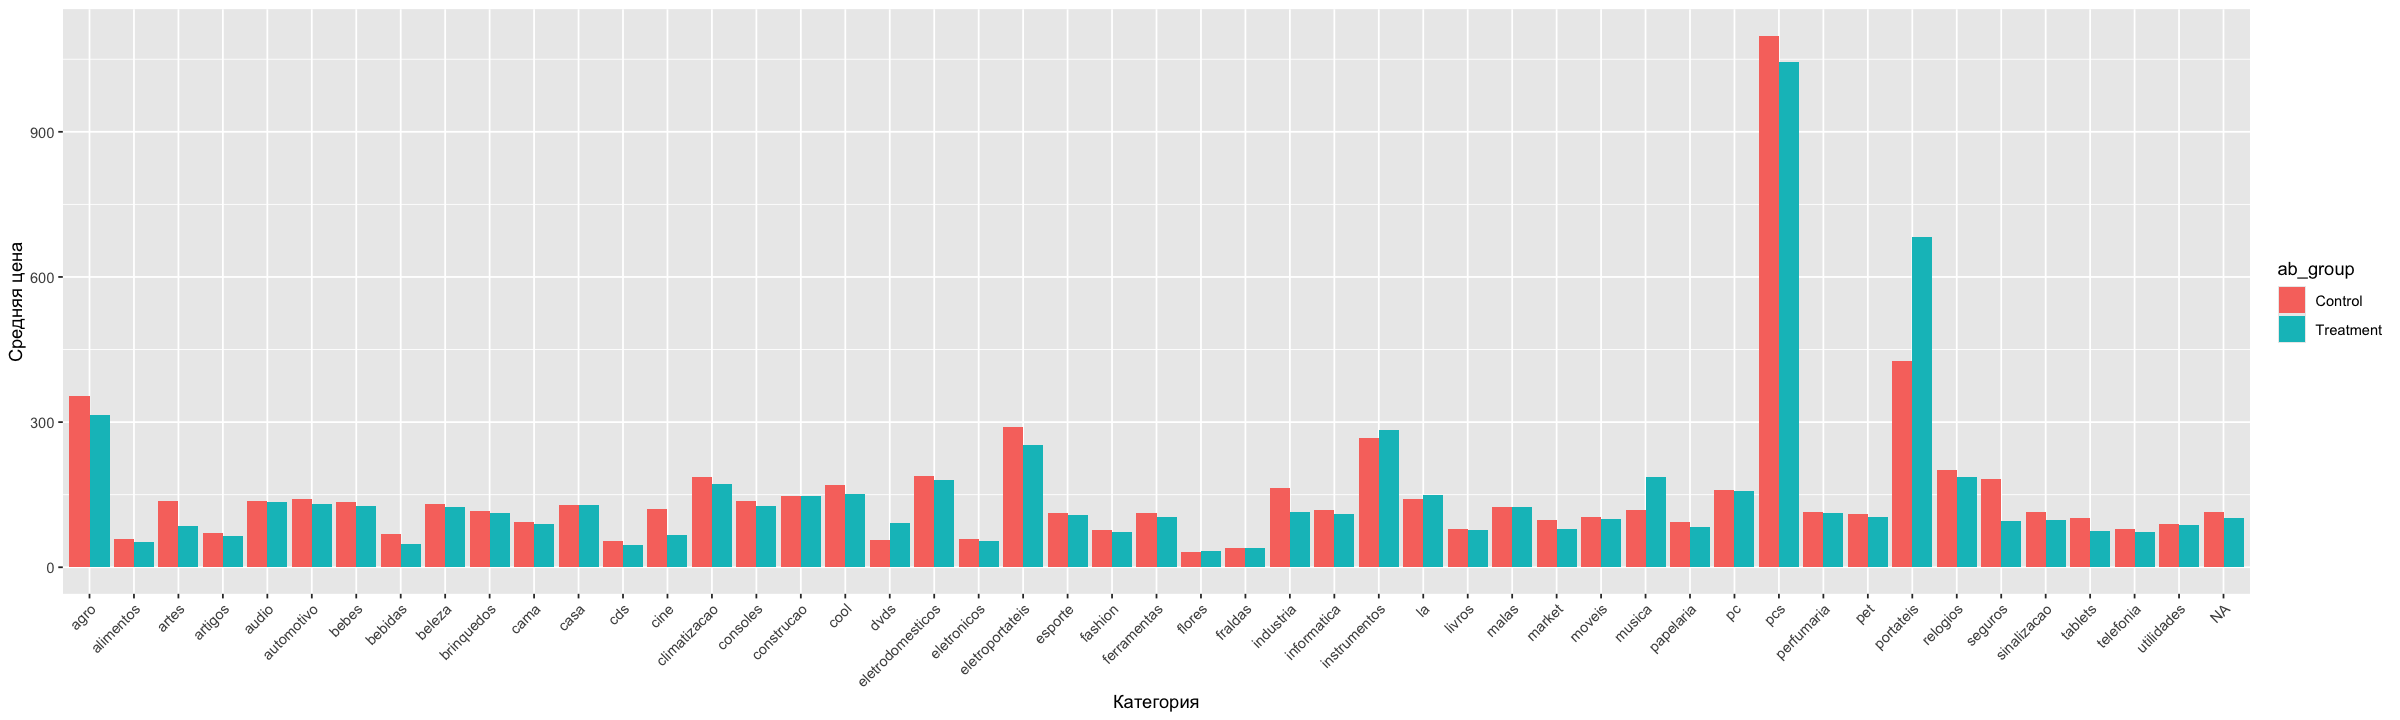

In [26]:
old_plot_opts <- options(repr.plot.width = 20, repr.plot.height = 6)

ab_cat_test_long <- ab_cat_test %>%
  pivot_longer(
    c(mean_control, mean_treatment), names_to = "ab_group", values_to = "mean_price", names_prefix = "mean_"
  ) %>%
  mutate(ab_group = str_to_title(ab_group))

ggplot(ab_cat_test_long, aes(category_main, mean_price, fill = ab_group)) +
  geom_col(position = position_dodge()) +
  labs(x = "Категория", y = "Средняя цена") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

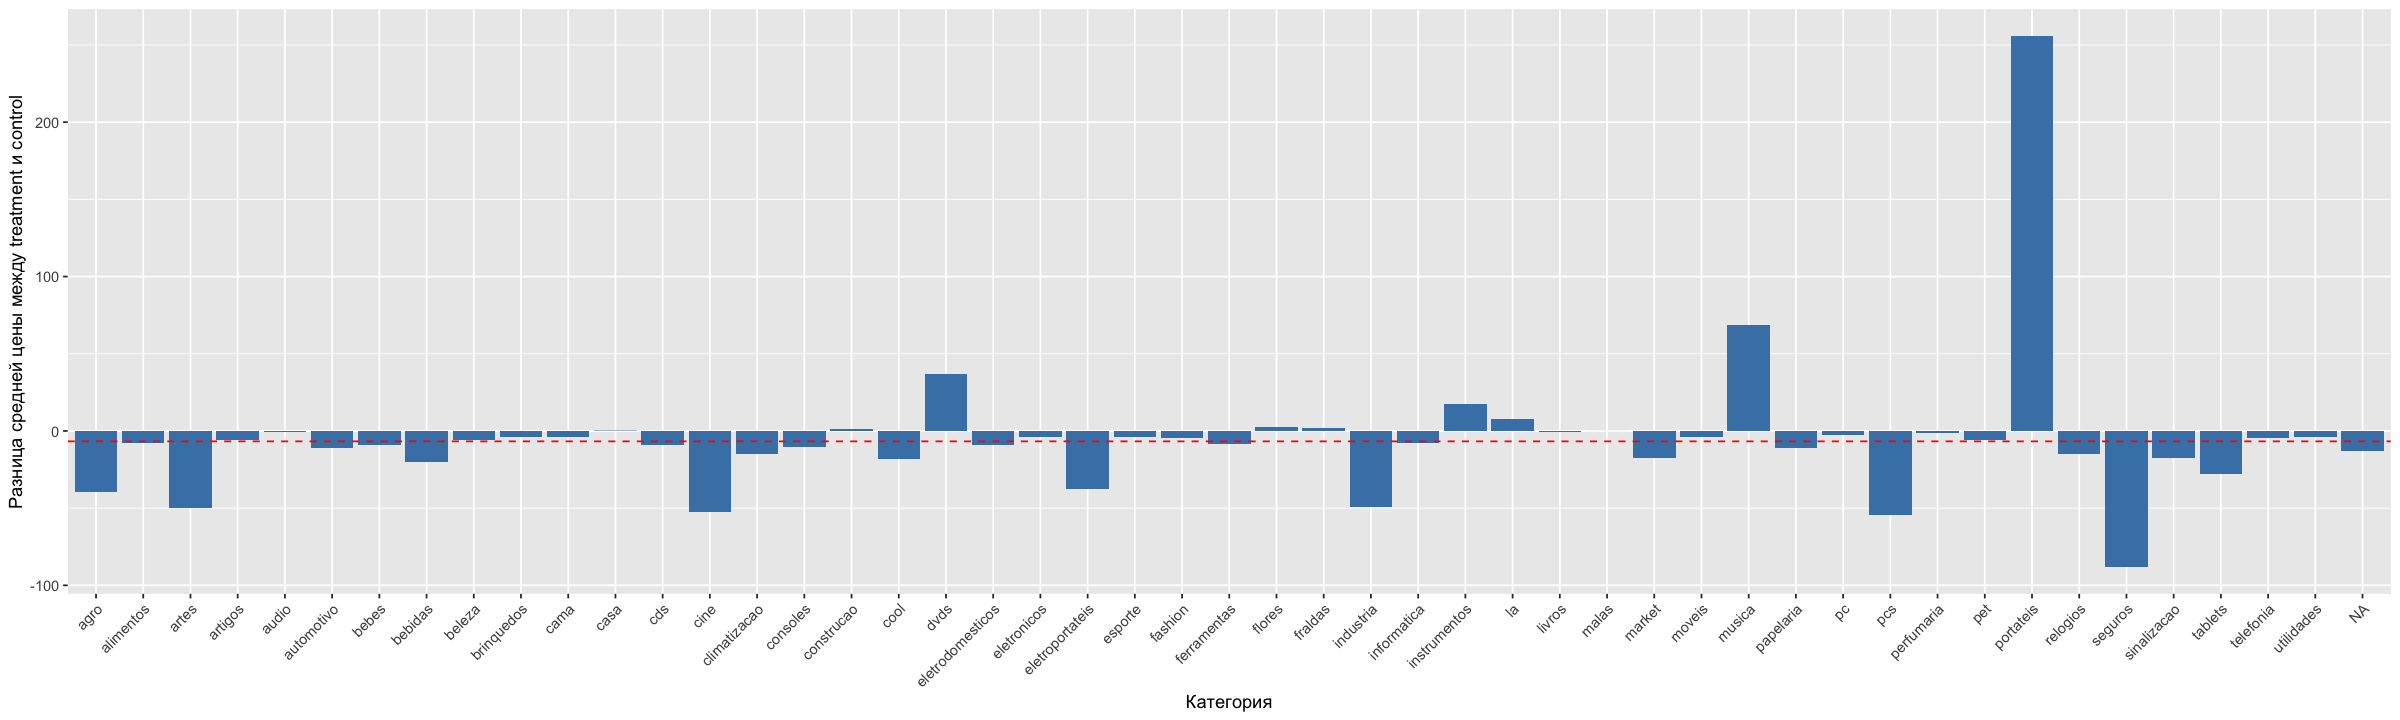

In [27]:
ggplot(ab_cat_test, aes(category_main, diff)) +
  geom_col(fill = "steelblue") +
  geom_hline(yintercept = diff(t_overall$estimate), linetype = "dashed", color = "red") +
  labs(x = "Категория", y = "Разница средней цены между treatment и control") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”


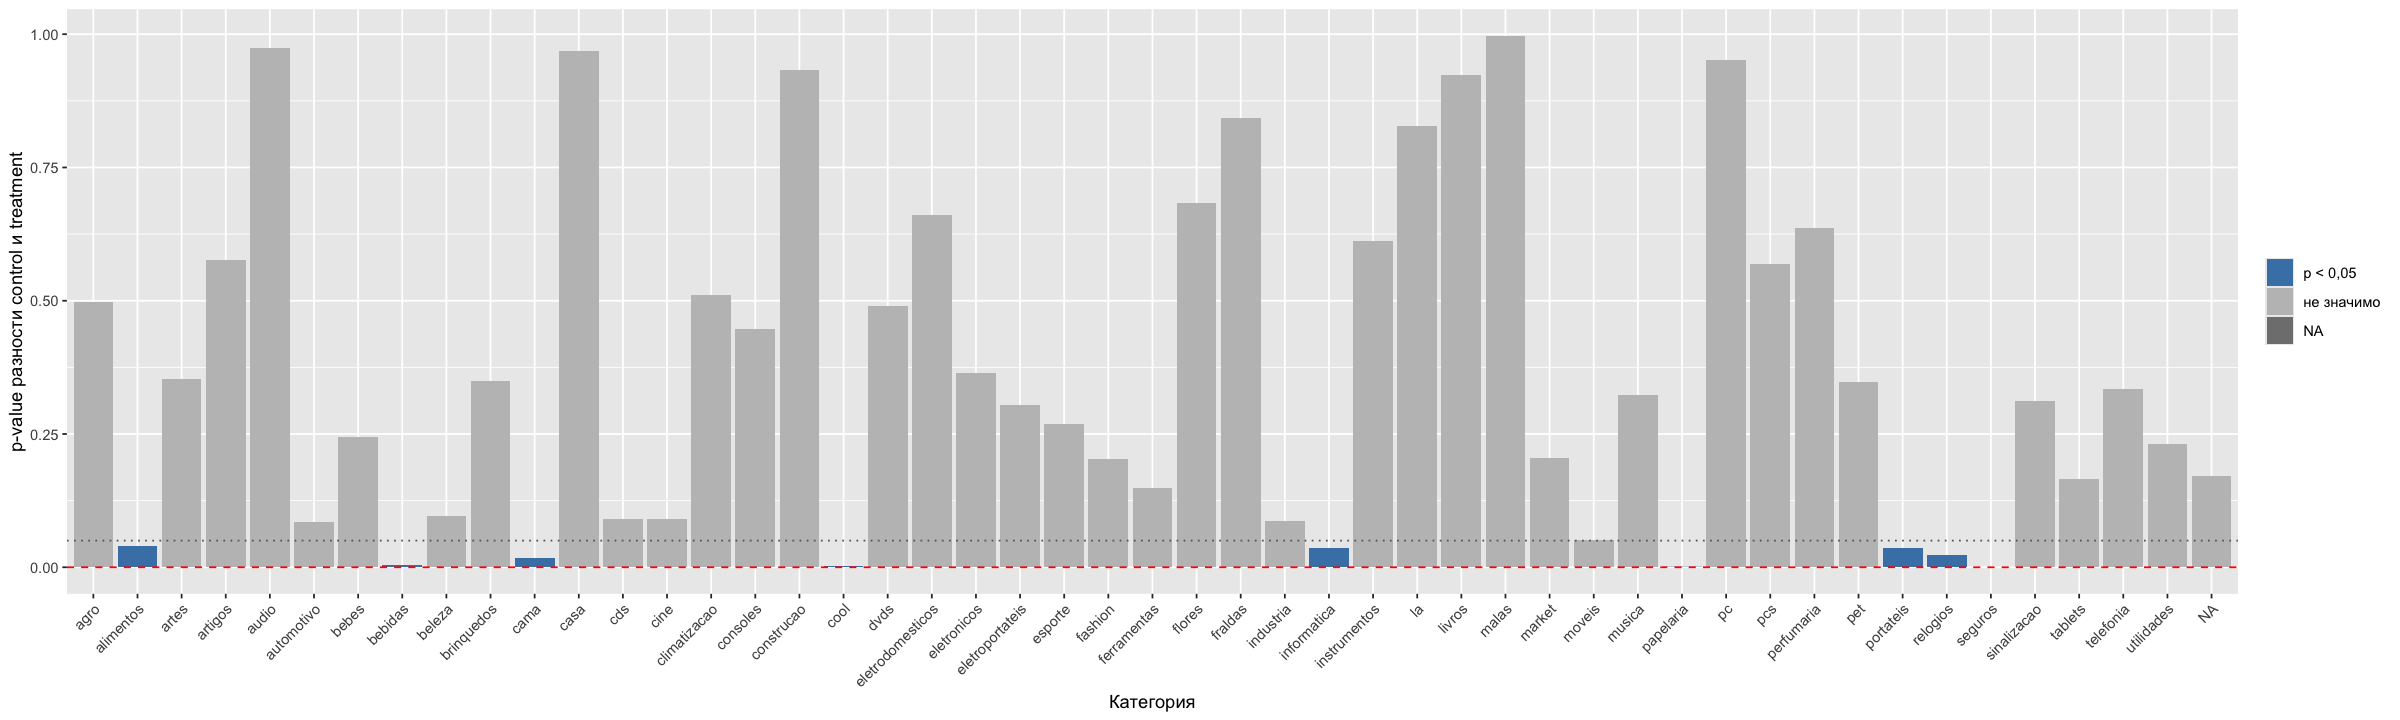

In [28]:
ggplot(
  ab_cat_test %>%
  mutate(sig = if_else(p_value < 0.05, "p < 0,05", "не значимо")),
  aes(category_main, p_value, fill = sig)
) +
  geom_col() +
  scale_fill_manual(values = c("p < 0,05" = "steelblue", "не значимо" = "gray75")) +
  geom_hline(yintercept = 0.05, linetype = "dotted", color = "gray40") +
  geom_hline(yintercept = t_overall$p.value, linetype = "dashed", color = "red") +
  labs(x = "Категория", y = "p-value разности control и treatment", fill = NULL) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

options(old_plot_opts)

Агрегированный результат теста показывает статистически значимое снижение метрики между контрольной и тестовой группами. Однако при анализе того же результата внутри сегментов по категории товара, результат оказывается совершенно неоднозначным: в некоторых категориях наблюдается экстремальное снижение метрики (seguros), в других же напротив метрика значительно увеличилась (portateis), и лишь в единицах категорий результат похож на агрегированный. Аналогичная закономерность и в значимости выводов: лишь 9 категорий показывают статистически-значимое изменение метрики, а в большинстве категорий эффект не значим - это вовсе противоречит агрегированному результату.

> 1. Почему агрегированный результат теста может отличаться от результатов внутри сегментов?

В этом и заключается парадокс Симпсона: агрегированный результат зачастую обманчив и требует детализации по сегментам пользователей или товаров. Как в случае наших данных, эффект может проявляться в разных направления или лишь в малой доле категорий: закономерность, которую агрегированный результат не может показать. Например, установление скидки на хозяйственные товары вряд ли будет иметь эффект на покупку продуктов. Однако агрегированный результат покажет лишь усредненное значение, которое не отразит реальную суть изменений.

Хотя агрегированная статистика и может иметь некоторый смысл, для получения точных рекомендаций на пратике следует анализировать результаты более аккуратно. Общий показатель "смешивает" сегменты разной природы, в результате чего статистически значимый общий эффект не гарантирует однородность этого эффекта внутри категорий.

> 2. Нашли ли вы признаки нарушения рандомизации (SRM)?

Признаков нарушения рандомизации не обнаружено на уровне значимости 5% как на уровне всего набора данных, так и в отдельных категориях.

> 3. Какую группу клиентов в итоге стоит таргетировать этой фичей?

Фичу следует таргетировать на массовые категории со значимым эффектом в нужном направлении, а не полагаться на агрегированные выводы. По результатам теста, такая категория, пожалуй, одна - portateis. Хотя объем выборки в ней и не столь большой (всего 41 control и 46 treatment), в этой категории наблюдается необыкновенно большой и статистически значимый положительный рост.

### Задание 2.2. Панельная причинность (PLM / GEE) (3.5 балла)

Контекст: Оценка влияния качества сервиса на активность клиента.

1. Подготовьте панельные данные (olist_panel или telco_panel).
2. Запустите модель GEE (geeglm) для бинарной переменной is_active (или is_churned_monthly).
    * Используйте лаговые переменные (например, задержку доставки в прошлом месяце).
    * Укажите id и структуру корреляции.
3. Сравните стандартные ошибки с обычной логистической регрессией (glm).

> Вопросы для отчета:

1. Как учет внутренней корреляции наблюдений повлиял на значимость коэффициентов?
2. Почему мы используем лаговые переменные?
3. Обоснуйте выбор структуры корреляции (exchangeable vs ar1).


In [29]:
telco_gee <- telco_panel %>%
  arrange(customerID, month_index) %>%
  group_by(customerID) %>%
  mutate(tickets_lag1 = lag(num_support_tickets), calls_lag1 = lag(total_calls_mins)) %>%
  ungroup() %>%
  mutate(cluster_id = as.integer(factor(customerID)))

In [30]:
glm_model <- glm(
  # Для оценки качества сервиса целесообразно использовать не все признаки,
  # поэтому включаем только те, которые могут быть как-то с этим связаны
  is_churned_monthly ~ tenure + tickets_lag1 + calls_lag1 + TechSupport + TotalCharges,
  data = telco_gee,
  family = binomial
)
summary(glm_model)


Call:
glm(formula = is_churned_monthly ~ tenure + tickets_lag1 + calls_lag1 + 
    TechSupport + TotalCharges, family = binomial, data = telco_gee)

Coefficients:
                                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)                    -1.127e+00  5.388e-02 -20.913  < 2e-16 ***
tenure                         -1.508e-01  5.695e-03 -26.482  < 2e-16 ***
tickets_lag1                    8.655e-02  1.995e-02   4.338 1.44e-05 ***
calls_lag1                      3.271e-03  8.604e-05  38.019  < 2e-16 ***
TechSupportNo internet service -1.349e+00  1.058e-01 -12.746  < 2e-16 ***
TechSupportYes                 -7.290e-01  6.899e-02 -10.566  < 2e-16 ***
TotalCharges                   -7.764e-04  8.048e-05  -9.647  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 21680  on 227989  degrees of freedom
Residual deviance: 13729  on 227983  degrees of freedom
AIC: 1

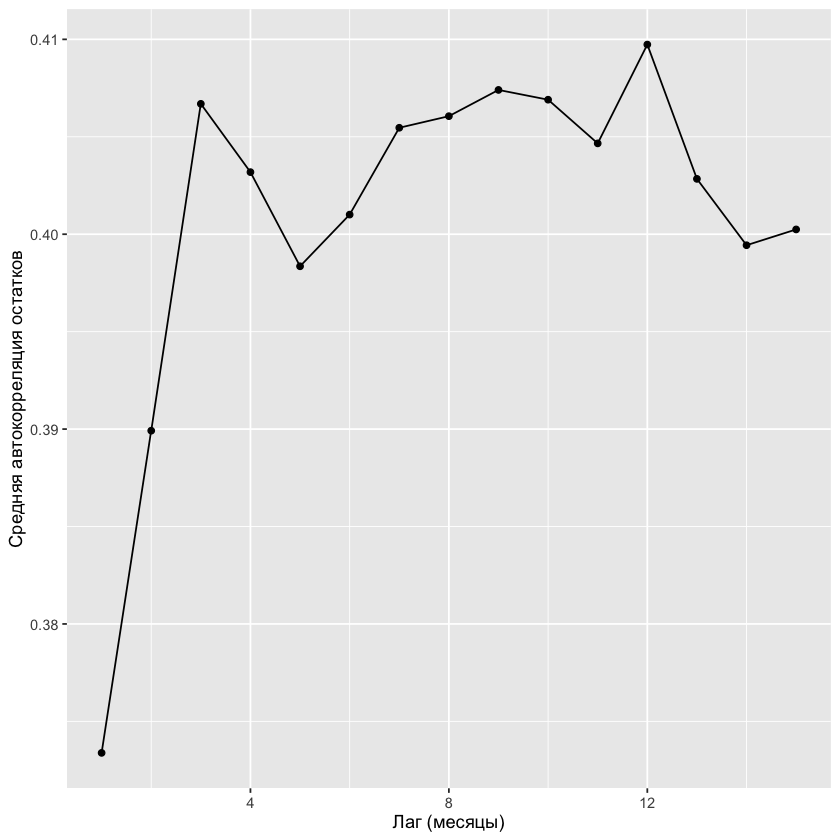

In [31]:
resid_data <- telco_gee %>%
  mutate(resid = residuals(glm_model, type = "pearson"))

acf_resid <- map_dfr(1:15, function(k) {
  resid_data %>%
    group_by(customerID) %>%
    mutate(resid_lag = dplyr::lag(resid, n = k)) %>%
    filter(!is.na(resid_lag)) %>%
    summarise(acf = cor(resid, resid_lag)) %>%
    summarise(lag = k, mean_acf = mean(acf, na.rm = TRUE))
})

acf_resid %>%
  ggplot(aes(lag)) +
  geom_line(aes(y = mean_acf)) +
  geom_point(aes(y = mean_acf)) +
  labs(x = "Лаг (месяцы)", y = "Средняя автокорреляция остатков")

options(old_plot_opts)

In [32]:
gee_model <- geeglm(
  is_churned_monthly ~ tenure + tickets_lag1 + calls_lag1 + TechSupport + TotalCharges,
  id = cluster_id,
  data = telco_gee,
  family = binomial,
  corstr = "exchangeable"
)
summary(gee_model)


Call:
geeglm(formula = is_churned_monthly ~ tenure + tickets_lag1 + 
    calls_lag1 + TechSupport + TotalCharges, family = binomial, 
    data = telco_gee, id = cluster_id, corstr = "exchangeable")

 Coefficients:
                                 Estimate    Std.err   Wald Pr(>|W|)    
(Intercept)                    -1.1336908  0.0575732 387.75  < 2e-16 ***
tenure                         -0.1506784  0.0078134 371.90  < 2e-16 ***
tickets_lag1                    0.0870020  0.0193437  20.23 6.87e-06 ***
calls_lag1                      0.0032613  0.0001086 901.79  < 2e-16 ***
TechSupportNo internet service -1.3468887  0.1095186 151.25  < 2e-16 ***
TechSupportYes                 -0.7286957  0.0638645 130.19  < 2e-16 ***
TotalCharges                   -0.0007695  0.0001091  49.72 1.78e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation structure = exchangeable 
Estimated Scale Parameters:

            Estimate Std.err
(Intercept)    2.655   62.21
  Link =

In [33]:
cbind(
  GLM = summary(glm_model)$coefficients,
  GEE = summary(gee_model)$coefficients
)

,GLM.Estimate,GLM.Std. Error,GLM.z value,GLM.Pr(>|z|),GEE.Estimate,GEE.Std.err,GEE.Wald,GEE.Pr(>|W|)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-1.1268370,5.388e-02,-20.913,4.084e-97,-1.1336908,0.0575732,387.75,0.000e+00
tenure,-0.1508190,5.695e-03,-26.482,1.566e-154,-0.1506784,0.0078134,371.90,0.000e+00
tickets_lag1,0.0865533,1.995e-02,4.338,1.440e-05,0.0870020,0.0193437,20.23,6.870e-06
calls_lag1,0.0032712,8.604e-05,38.019,2.766e-316,0.0032613,0.0001086,901.79,0.000e+00
TechSupportNo internet service,-1.3488587,1.058e-01,-12.746,3.291e-37,-1.3468887,0.1095186,151.25,0.000e+00
TechSupportYes,-0.7289546,6.899e-02,-10.566,4.302e-26,-0.7286957,0.0638645,130.19,0.000e+00
TotalCharges,-0.0007764,8.048e-05,-9.647,5.074e-22,-0.0007695,0.0001091,49.72,1.775e-12


**Ответ:**

Обе модели (GEE и GLM) показывают схожие результаты: коэффициенты для некоторых переменных совпадают практически в точности. Ни в одном коэффициенте не наблюдается изменения качественного вывода или его статистической значимости при смене модели.
- Лояльные клиенты (высокий tenure) менее подвержены оттоку, чем новые клиенты;
- Рост нагрузки на поддержку (tickets_lag1) статистически значимо свидетельствует о повышении вероятности оттока клиента;
- Клиенты с подключенной техподдержкой (TechSupport) уходят реже, чем без нее.

> 1. Как учет внутренней корреляции наблюдений повлиял на значимость коэффициентов?

Учет внутренней корреляции не повлиял на качественные выводы и их значимость. Однако стандартные ошибки несколько пересчитываются с учетом внутренней корреляции наблюдений. Так, отклонение tickets_lag1 практически не меняется, в то время как для calls_lag1 GEE дает большую ошибку. Тем не менее учет кластерной структуры не просто подтверждает значимость факторов, но и усиливает это предположение, делает оценку неопределенностей корректной с учетом особенностей панельных данных.

> 2. Почему мы используем лаговые переменные?

Число обращений и минут звонков в поддержку в текущем месяце могут не отражать реальное снижение качества сервиса, которое привело к оттоку клиента. Клиент уже недоволен сервисом, в результате чего чаще обращается в поддержку и в итоге уходит в том же месяце.

Использование лаговых переменных позволяет учесть влияние качества сервиса на целевую переменную более корректно. Рассмотрение числа обращение за месяц до оттока позволяет интерпретировать их как предшествующий опыт обслуживания, отражающий реальное снижение качества сервиса, а не как реакцию на сам факт оттока. Это позволяет явно выделить причину оттока и не смешивать ее со следствием.

> 3. Обоснуйте выбор структуры корреляции (exchangeable vs ar1).

Визуализация средней автокорреляции остатков показывает практически одинаковую корреляцию наблюдений независимо от рассматриваемого лага. Это согласуется с exchangeable структурой: корреляция между любыми двумя месяцами одного клиента примерно одинаковая. Для выбора ar1 требовалось бы, чтобы корреляция затухала геометрически с увеличением лага, что явно не проявляется в рассмотренных данных.